# Notebook Setup

In [33]:
# @title
import os
#os.listdir('/Users/viv/OneDrive/Work/Ultimate/Incognito/')

print(os.getcwd())

/content


In [34]:
# Setup
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output
import io
import datetime as dt

## Install itables if not already installed and import it
try:
    import itables.interactive
except ImportError:
    %pip install itables
    import itables.interactive

# Enable interactive mode for all DataFrames
# itables.interactive.init_notebook_mode(all_interactive=False)

## Wrap text pandas table output
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

# Load & clean data
df = pd.read_csv('/content/2026_Toronto_Womens_Tryout_Form_Responses.csv')

## Strip whitespace from column names
df.columns = df.columns.str.strip()

df = df.astype({'Timestamp': 'datetime64[ns]', 'Date of Birth': 'datetime64[ns]'})

## Add Age column
df['Age'] = (dt.datetime.now().year - df['Date of Birth'].dt.year)

## Clean Player Names
df['Name_clean'] = df['Name'].astype(str).str.strip()

# Subsets of Players

## All Players

In [35]:
# @title
# print(df['I am trying out for: '].unique())

In [36]:
# @title
print(f"Total Number of Form Responses: {df['Name_clean'].nunique()}")

Total Number of Form Responses: 69


### All Form Responses

In [37]:
display(df)

,Timestamp,PAID?,Name,I am trying out for:,Email Address,Phone Number,Date of Birth,Please rank your preferences for the teams you are trying out for. [6ixers],Please rank your preferences for the teams you are trying out for. [Incognito],Please rank your preferences for the teams you are trying out for. [Mixed ],...,What line have you historically played on?,"Please list any teams you have played for in the last 3 years (2023, 2024, 2025 seasons), as well as any notable accomplishments from these seasons.","In 3 sentences or less, describe the role you see yourself playing on a Toronto Women's team.",Complete this statement: The best way to describe how I feel about playing time is...,"6IXERS ONLY - Complete this statement: Overall, my priority is...",Please list two references and their contact info.,Is there anything else that you would like us to know?,Please e-transfer the tryout fee of $50 within 48 hours(!!) of completing this form to 6ixersultimate@gmail.com. Include your name in the message.,Age,Name_clean
0,2026-02-28 21:02:57,YES,Alyssa Mason,6ixers only,alyssadaniellemason@gmail.com,5198419028,1997-12-23,1st choice,NaN,NaN,...,Defense,NaN,NaN,It is not important to me,"To be on the most elite team possible, even if it means very little playing time",NaN,NaN,I am amazing and have already sent my EMT,29,Alyssa Mason
1,2026-03-01 09:25:08,NaN,Jessie Tsang,6ixers only,jessie.tsang14@gmail.com,4168963232,1998-04-06,1st choice,NaN,NaN,...,Defense,6ixers,captain 🫡,I am happy as long as I play 4-5 points in each game,"To be on the most elite team possible, even if it means very little playing time",britt and alyssa,NaN,I will send it ASAP!,28,Jessie Tsang
2,2026-03-01 09:47:26,NaN,Maia List,6ixers only,maia.aa.list@gmail.com,4165198899,2004-09-27,1st choice,3rd choice,2nd choice,...,Defense,"6ixers 2024 & 2025, McGill Open A 2025 & 2026, Incognito 2023, McGill Women’s A 2022-2025 (captain 2024 & 2025)",D line DAWG. I want to use my hunger and athleticism to be one of the most annoying defenders out there.,I am happy as long as I play 1-2 points in each game,"To be on the most elite team possible, even if it means very little playing time",Carla & Jordo <3,"I am unable to attend the tryout on April 16th as I have a final (unmovable) in Montreal during the tryout. However, I will be there for the tryout on the 19th! Please let me know if you would also like me to attend the Incog tryout on the 25th to make up for not attending the first tryout.",I will send it ASAP!,22,Maia List
3,2026-03-01 10:03:07,YES,Tyama Lyall,6ixers only,tyamasjunction@gmail.com,647-861-7959,2000-06-29,1st choice,3rd choice,4th choice,...,Defense,"6ixers, TC U24 W 2023, TC W 2024, TC beach W 205","I see myself as a D line handler who can take difficult matchups and play very good defense on whoever I’m guarding. I see myself as someone who would be very involved offensively but maybe not necessarily taking a lot of risky shots, I tend to prefer safer options. R.e., the questions about PT, I know how deep 6ixers is and I don’t get upset if I don’t have the most PT on the team, but it is a goal of mine to be a strong player on the team and to be good enough to feel like I deserve to play in important games",I am happy as long as I play 4-5 points in each game,"To be on the most elite team possible, even if it means very little playing time",Jordo & Carla :),I might go on a trip around the end of May. It wouldn’t conflict with any tournaments but I might miss 2-3 practices. I’ll try to plan it to miss as little as possible. If this is a big issue and would impact whether I make the team or not please let me know,I will send it ASAP!,26,Tyama Lyall
4,2026-03-01 10:37:00,YES,Brittney Dos Santos,6ixers only,brittneydossantos07@gmail.com,6476317157,1999-10-07,1st choice,NaN,NaN,...,Offense,6ixers,Anything,It is important for me to play a lot - I struggle when I don't get to play in big moments,"To be on the most elite team possible, even if it means very lit

## Cog Eligible

In [38]:
# @title
# Cog inclusive
df_cog_inclusive = df[df['I am trying out for:'].str.contains("Incognito")]
df_cog_only = df[df['I am trying out for:'].str.contains("Incognito only")]

#df_cog.head(5)

print(f"Cog Eligible: {df_cog_inclusive['Name_clean'].nunique()}")
print(f"Cog Only: {df_cog_only['Name_clean'].nunique()}")


Cog Eligible: 39
Cog Only: 21


## Invited to 6ixers Tryout 1

In [39]:
# @title
# Invited to 6ixers Tryout 1

df_6ixers_tryout1_invites = pd.read_csv(io.StringIO('''
Invites
Alyssa Mason
Jessie Tsang
Maia List
Tyama Lyall
Brittney Dos Santos
Sarah Lam
Sabrina Trung
Chloe Ringler
Hannah Dawson
Jessica Hou
Molly Lewis
Reve Chan
Jade
Melanie Tran
rachel cooc
Makayla Power
Jazmin Ulalan
Grażyna Chlebicka
Krystal Dos Santos
Jocelyn Li
belle ouyang
Mika Kurahashi
Joely Valencerina
Monica wang
Molly Wedge
Grace Wang
Huicong Lay
Eastelle
Aryanie Yang
Joyce Lei
Ava Pearson
'''))

In [40]:
# @title
df_cog_tryout1 = df_cog_inclusive[~df_cog_inclusive['Name_clean'].isin(df_6ixers_tryout1_invites['Invites'])]
#df_cog_tryout1.head(5)

print(f"Cog Tryout 1: {df_cog_tryout1['Name_clean'].nunique()}")

Cog Tryout 1: 35


## Cog Tryout 1 Attendees

In [41]:
# @title
# Display the DataFrame interactively
display(df_cog_tryout1)

,Timestamp,PAID?,Name,I am trying out for:,Email Address,Phone Number,Date of Birth,Please rank your preferences for the teams you are trying out for. [6ixers],Please rank your preferences for the teams you are trying out for. [Incognito],Please rank your preferences for the teams you are trying out for. [Mixed ],...,What line have you historically played on?,"Please list any teams you have played for in the last 3 years (2023, 2024, 2025 seasons), as well as any notable accomplishments from these seasons.","In 3 sentences or less, describe the role you see yourself playing on a Toronto Women's team.",Complete this statement: The best way to describe how I feel about playing time is...,"6IXERS ONLY - Complete this statement: Overall, my priority is...",Please list two references and their contact info.,Is there anything else that you would like us to know?,Please e-transfer the tryout fee of $50 within 48 hours(!!) of completing this form to 6ixersultimate@gmail.com. Include your name in the message.,Age,Name_clean
8,2026-03-02 09:17:59,YES,Sharra,Both 6ixers and Incognito,sharra.pearson@gmail.com,6473213815,2008-09-10,1st choice,2nd choice,3rd choice,...,Offense,"Toro Women's 2024, Team Canada East 2025 (finals MVP), Sauga Open 2025, Team Canada U20 2026.","As an experienced handler, I am a player that thrives in high-pressure situations. I'm accustomed to running offenses as well as transitioning from offense to defense. As an athlete, I am used to amplifying the pace of the game, but as a handler, I know when to slow it down.",I am happy as long as I play 4-5 points in each game,"To be on the most elite team possible, even if it means very little playing time",Ywan Cohonner (ywancohonner@live.ca)\nKrystal Dos Santos (krystalhdossantos@gmail.com),"I would be most happy with a PR spot on 6ixers, as my main goal for this summer is to work hard and improve as much as possible while surrounded by incredible players, since I will be away for a large chunk of it.",I will send it ASAP!,18,Sharra
10,2026-03-02 16:23:10,YES,Sabrina Paez-Parent,Both 6ixers and Incognito,sabrina.paez.parent@gmail.com,437 9989890,1990-11-16,1st choice,2nd choice,3rd choice,...,Defense,"Canadian Ultimate Championships (CUC / CUCM) – Masters Women’s (2023–2025) \nCanadian Team - Lore \n\n2023: Ranked 45th of 253 Masters Women players nationally\n\n2024: Ranked 41st of 269 Masters Women players nationally\n\n2025: Captain \n\nDemonstrated consistent offensive and defensive impact across multiple seasons, including goals, assists, and point conversion efficiency\n\nProven ability to perform in high-pressure national competition; key power line defensive line player\n\nPan American Ultimate Championships (PAUC) – Women’s Club (2025)\nVenezuelan Team - Spanglish \n\nSpirit of the Game Award Winner\n\nCompeted at the international level against elite club teams from across the Americas\n\nHarvest Ultimate Tournament – Mixed Masters (2025)\nCanadian Team - Candy Shop \n\nHigh-level mixed Masters competition emphasizing adaptability, field awareness, and chemistry across divisions\n\nLei Out Tournament – Mixed (2026)\nAmerican / Canadian Mixed Team - DND\n\n15th place out of 60+ teams, significantly outperforming seed\n\nDemonstrated ability to integrate quickly with international teammates and contribute effectively in mixed-gender play\n\nPending - \nTEP in Colombia April 2026 Seniors Mixed - Parlay (Chicago)\nMasters Worlds June 2026 - Mixed Candela (México)",I strive to be a reliable cutter on an offensive or defensive line. I want to play hard defense so we can turn the game a score and I do everything in my ability to make that happen. Supporting and growing women's ultimate is a role I see myself in on the team and in the broader Toronto scene.,I am happy as long as I play 1-2 points in each game,"To be on the most elite team possible, even if it means very little playing time",Vikki Shinoda vikkishimoda@gmail.com\nViv Yuen vivien.ly.94@gmail.com,I am exc

### See Specific Form Responses

In [42]:
# @title
import ipywidgets as widgets
import pandas as pd
from IPython.display import display, clear_output, HTML

# Initialize a global variable for the selected DataFrame within this widget's context
df_selection_state = pd.DataFrame()

# --- DataFrame Selection Logic ---

def get_dataframes():
    dataframes = []
    for name, obj in globals().items():
        if isinstance(obj, pd.DataFrame) and name != 'df_selection_state': # Exclude df_selection_state itself
            dataframes.append(name)
    return sorted(dataframes)

dataframe_names = get_dataframes()
if not dataframe_names:
    dataframe_names = ['No DataFrames found']

# Widgets for DataFrame selection
df_dropdown = widgets.Dropdown(
    options=dataframe_names,
    description='Select DataFrame:',
    disabled=False,
    layout=widgets.Layout(width='50%')
)
df_selection_output = widgets.Output()

# --- Player Search Logic ---
search_box = widgets.Text(
    placeholder='Type part of a name...',
    description='Search Player:',
    layout=widgets.Layout(width='50%')
)

name_matches_dropdown = widgets.Dropdown(
    options=[],
    description='Matches:',
    layout=widgets.Layout(width='50%')
)

player_search_output = widgets.Output()

# Function to update player search dropdown based on search and current df
def update_name_dropdown(change=None):
    global df_selection_state
    if df_selection_state.empty or 'Name_clean' not in df_selection_state.columns:
        name_matches_dropdown.options = ['No valid players in selected DataFrame']
        name_matches_dropdown.value = 'No valid players in selected DataFrame'
        return

    search_value = search_box.value.strip().lower()

    if search_value == "":
        matches = df_selection_state['Name_clean'].unique()
    else:
        matches = df_selection_state.loc[
            df_selection_state['Name_clean'].str.lower().str.contains(search_value, na=False),
            'Name_clean'
        ].unique()

    if len(matches) == 0:
        name_matches_dropdown.options = ['No matches found']
        name_matches_dropdown.value = 'No matches found'
    else:
        sorted_matches = sorted(matches)
        name_matches_dropdown.options = sorted_matches
        # If the current value is no longer in options, set to first valid option
        if name_matches_dropdown.value not in sorted_matches:
            name_matches_dropdown.value = sorted_matches[0]

# Function to display selected player's details
def display_player_details(change=None):
    global df_selection_state
    with player_search_output:
        clear_output()

        selected_name = name_matches_dropdown.value

        if selected_name in ['No matches found', 'No valid players in selected DataFrame']:
            print(selected_name)
            return

        if not df_selection_state.empty and 'Name_clean' in df_selection_state.columns:
            df_player = df_selection_state.loc[df_selection_state['Name_clean'] == selected_name]

            if not df_player.empty:
                df_player_long = (
                    pd.melt(df_player, id_vars=['Name'], var_name='Question', value_name='Answer')
                    .drop(columns=['Name'])
                )
                # Explicitly render to HTML to ensure static display
                display(HTML(df_player_long.to_html(index=False)))
            else:
                print(f"No details found for player: {selected_name}")
        else:
            print("Cannot display player details. Please select a valid DataFrame.")

# Function to select and display dataframe (modified to integrate player search)
def select_dataframe(change):
    global df_selection_state
    with df_selection_output:
        clear_output()
        selected_df_name = change.new
        if selected_df_name == 'No DataFrames found':
            print("No DataFrame selected or found.")
            df_selection_state = pd.DataFrame() # Assign an empty DataFrame
            # Clear player search widgets
            search_box.value = ""
            name_matches_dropdown.options = []
            with player_search_output:
                clear_output()
                print("Please select a DataFrame.")
            return

        # Retrieve the selected DataFrame object and assign a copy to df_selection_state
        selected_df_obj = globals()[selected_df_name]
        df_selection_state = selected_df_obj.copy() # Work on a copy to avoid modifying original source dataframes

        # Apply cleaning steps
        if 'Name' in df_selection_state.columns and 'Name_clean' not in df_selection_state.columns:
            df_selection_state['Name_clean'] = df_selection_state['Name'].astype(str).str.strip()
        elif 'Name' not in df_selection_state.columns and 'Name_clean' not in df_selection_state.columns:
            print("Warning: 'Name' column not found to create 'Name_clean'. Player search may not function correctly.")
            df_selection_state['Name_clean'] = '' # Ensure Name_clean column exists, even if empty

        if 'Timestamp' in df_selection_state.columns and not pd.api.types.is_datetime64_any_dtype(df_selection_state['Timestamp']):
            try:
                df_selection_state['Timestamp'] = pd.to_datetime(df_selection_state['Timestamp'], errors='coerce')
            except Exception as e:
                print(f"Warning: Could not convert 'Timestamp' to datetime: {e}")

        if 'Date of Birth' in df_selection_state.columns and not pd.api.types.is_datetime64_any_dtype(df_selection_state['Date of Birth']):
            try:
                df_selection_state['Date of Birth'] = pd.to_datetime(df_selection_state['Date of Birth'], errors='coerce')
            except Exception as e:
                print(f"Warning: Could not convert 'Date of Birth' to datetime: {e}")

        # print(f"Selected DataFrame '{selected_df_name}'. DataFrame head:")
        # display(df_selection_state.head())
        print(f"Unique Players: {df_selection_state.shape[0]}")

    # After df_selection_state is updated and cleaned, update the player search dropdown and display player details
    update_name_dropdown() # Initial update for player search dropdown options
    display_player_details() # Initial display for player search output

# Link interactions for DataFrame selection
df_dropdown.observe(select_dataframe, names='value')

# Link interactions for Player search
search_box.observe(update_name_dropdown, names='value')
name_matches_dropdown.observe(display_player_details, names='value')

# Initialize DataFrame selection and player search
if dataframe_names and dataframe_names[0] != 'No DataFrames found':
    select_dataframe({'new': dataframe_names[0]}) # Manually trigger for initial display
else:
    with df_selection_output:
        print("No DataFrames available in the current environment to select.")
    # Also initialize player search widgets to empty state if no DataFrames are found
    update_name_dropdown()
    display_player_details()

# Display UI
display(widgets.VBox([
    widgets.HBox([df_dropdown, df_selection_output]),
    widgets.HBox([search_box, name_matches_dropdown]),
    player_search_output
]))


### Summary & Distribution of Responses

#### Contingency Table: Position vs. Line Played

In [43]:
# @title
contingency_table = pd.crosstab(df['What position do you typically play?'], df['What line have you historically played on?'])
display(contingency_table)

What line have you historically played on?,Defense,Not sure,Offense
What position do you typically play?,,,
Cutter,28,1,5
Handler,10,2,6
Hybrid,9,4,4


#### Age Distribution

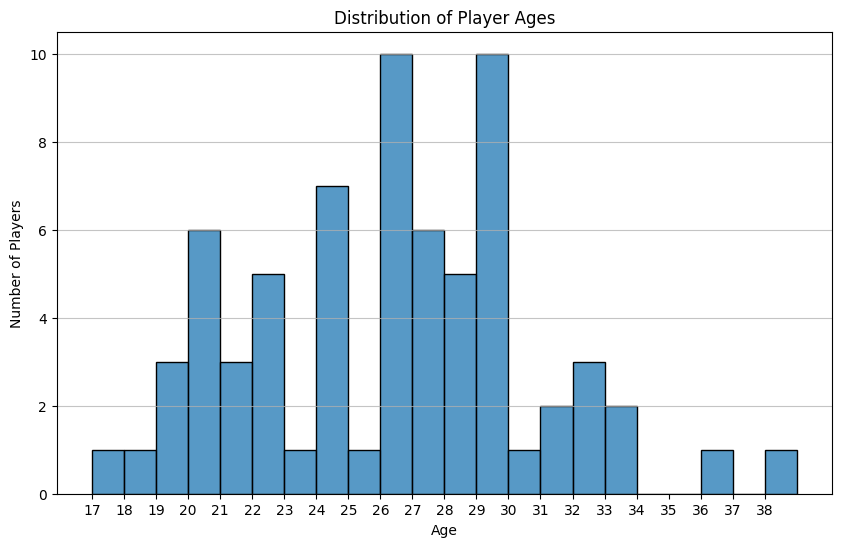

In [44]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Age'].dropna(), bins=range(min(df['Age'].dropna().astype(int)), max(df['Age'].dropna().astype(int)) + 2), kde=False)
plt.title('Distribution of Player Ages')
plt.xlabel('Age')
plt.ylabel('Number of Players')
plt.xticks(range(min(df['Age'].dropna().astype(int)), max(df['Age'].dropna().astype(int)) + 1))
plt.grid(axis='y', alpha=0.75)
plt.show()

#### Selected Mixed among Preferences

In [45]:
# @title
df_cogT1_mixed = df_cog_tryout1[df_cog_tryout1['Please rank your preferences for the teams you are trying out for.  [Mixed ]']
                                .notna()][['Name_clean', 'Email Address', 'Please rank your preferences for the teams you are trying out for.  [Mixed ]']]
df_cogT1_mixed

,Name_clean,Email Address,Please rank your preferences for the teams you are trying out for. [Mixed ]
8,Sharra,sharra.pearson@gmail.com,3rd choice
10,Sabrina Paez-Parent,sabrina.paez.parent@gmail.com,3rd choice
12,Christine Huang,hchristine006@gmail.com,3rd choice
15,Zoey Drassinower,thisemailistaken23@gmail.com,1st choice
16,Viola Song,violasong0314@gmail.com,3rd choice
19,Clara Narimatsu,claranarimatsu@gmail.com,3rd choice
20,Joanna Kolovos,kolovosjoanna@gmail.com,2nd choice
24,Naomi Lew,naomilew09@gmail.com,2nd choice
25,Kate Thresher,katie.thresher@icloud.com,3rd choice
26,Cathy Wan,cathyyuwan@gmail.com,3rd choice


# Evaluation Form Setup

In [46]:
unique_names_cog_tryout1 = df_cog_tryout1['Name_clean'].unique()
df_eval_cog_tryout1 = pd.DataFrame(unique_names_cog_tryout1, columns=['Name_clean'])
df_eval_cog_tryout1['O with Disc'] = pd.NA
df_eval_cog_tryout1['D with Disc'] = pd.NA
df_eval_cog_tryout1['O without Disc'] = pd.NA
df_eval_cog_tryout1['D without Disc'] = pd.NA
df_eval_cog_tryout1['Creativity'] = pd.NA
df_eval_cog_tryout1['Resilience'] = pd.NA
df_eval_cog_tryout1['Comments'] = pd.NA



In [47]:
# Export to CSV
df_eval_cog_tryout1.to_csv('df_eval_cog_tryout1.csv', index=False)